In [13]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay

In [14]:
# Load the dataset
df = pd.read_csv("breast-cancer.csv")

# Display column names
print(df.columns.tolist())

['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [15]:
# Convert target labels
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Separate features and target
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)
from sklearn.model_selection import train_test_split

Features Shape : (569, 30)
Target Shape   : (569,)


In [16]:
# Split the dataset into 75% training and 25% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (426, 30)
Testing Samples  : (143, 30)


In [17]:
# Train the model using Logistic regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [21]:
#perform k fold cross validation
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring="accuracy"
)
print("Accuracy of each fold:\n")
for i, score in enumerate(scores):
    print(f"Fold {i+1}: {score:.4f}")
print("\nAverage Accuracy:", scores.mean())

Accuracy of each fold:

Fold 1: 0.9561
Fold 2: 0.9649
Fold 3: 0.9386
Fold 4: 0.9737
Fold 5: 0.9204

Average Accuracy: 0.9507374631268437


In [22]:
# Predict the Test Data
y_pred = model.predict(X_test)
# Compute Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9440559440559441
Precision: 0.9787234042553191
Recall   : 0.8679245283018868
F1 Score : 0.92


In [23]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix")
print(cm)

Confusion Matrix
[[89  1]
 [ 7 46]]


In [24]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96        90
           1       0.98      0.87      0.92        53

    accuracy                           0.94       143
   macro avg       0.95      0.93      0.94       143
weighted avg       0.95      0.94      0.94       143



In [25]:
# ROC-AUC Score
from sklearn.metrics import roc_auc_score
y_prob = model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9949685534591195


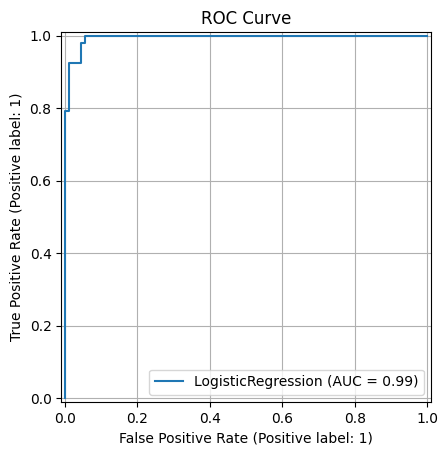

In [26]:
# Plot Roc Curve
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.grid(True)
plt.show()

In [27]:
# Compare Train-Test Split and K-Fold Cross Validation
import pandas as pd
comparison = pd.DataFrame({
    "Evaluation Method": ["Train-Test Split", "5-Fold Cross Validation"],
    "Accuracy": [accuracy, scores.mean()]
})
print(comparison)

         Evaluation Method  Accuracy
0         Train-Test Split  0.944056
1  5-Fold Cross Validation  0.950737
